# Gráficos — Atividade 01 (IA001)

Notebook separado, só para gerar os gráficos das perguntas de análise.

**Dataset:** `dataset_principal.csv` — Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP).

## Preparação do ambiente

In [1]:
# imports (pandas, matplotlib, etc.)
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Carregamento e limpeza dos dados

In [2]:
CAMINHO_CSV = "../dataset_principal.csv" 
 
df = pd.read_csv(CAMINHO_CSV)
df = df.iloc[:-3]  # remove a linha em branco + as 2 linhas de crédito/fonte do rodapé

municipios = df[~df["Territorialidades"].isin(["Brasil", "Rio Grande do Sul"])].copy()

print(df.head())  # Display the first few rows of the DataFrame

   Territorialidades % dos ocupados com ensino médio completo 2010  \
0             Brasil                                         44.91   
1  Rio Grande do Sul                                         43.64   
2        Aceguá (RS)                                         21.42   
3    Água Santa (RS)                                         29.12   
4         Agudo (RS)                                         23.35   

   Rendimento médio dos ocupados 2010  % dos ocupados sem rendimento 2010  \
0                             1296.19                                5.58   
1                             1332.67                                5.04   
2                             1112.46                                2.78   
3                             1125.67                               15.46   
4                             1043.29                               10.95   

   % dos ocupados com rendimento de até 1 salário mínimo 2010  \
0                                              21.9

## Pergunta 1

Municípios onde mais ocupados têm ensino médio completo pagam melhor?

Municípios com os dois indicadores preenchidos: 496
Municípios com os dois indicadores preenchidos: 496


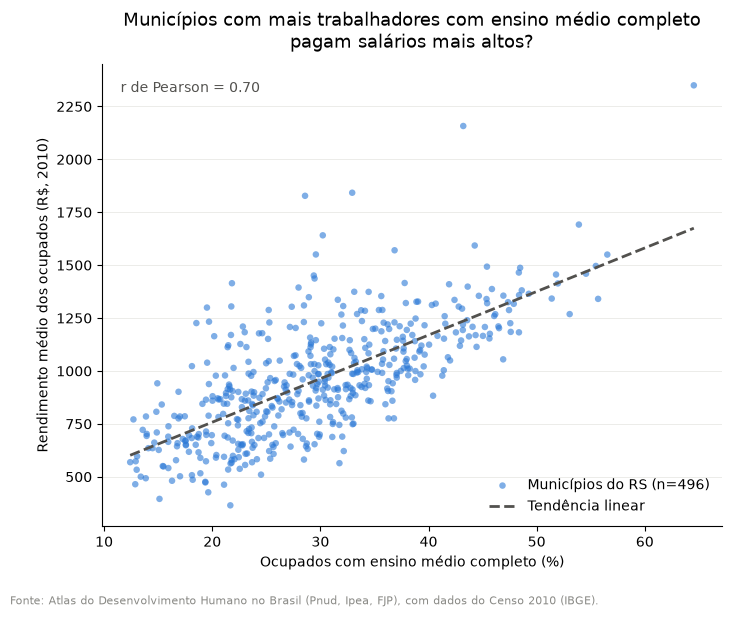

In [3]:
# código do gráfico da pergunta 1
col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_renda = "Rendimento médio dos ocupados 2010"
 
for col in [col_escolaridade, col_renda]:
    municipios[col] = pd.to_numeric(municipios[col], errors="coerce")
 
municipios = municipios.dropna(subset=[col_escolaridade, col_renda])
print(f"Municípios com os dois indicadores preenchidos: {len(municipios)}")

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
col_renda = "Rendimento médio dos ocupados 2010"
 
for col in [col_escolaridade, col_renda]:
    municipios[col] = pd.to_numeric(municipios[col], errors="coerce")
 
municipios = municipios.dropna(subset=[col_escolaridade, col_renda])
print(f"Municípios com os dois indicadores preenchidos: {len(municipios)}")
 
# ---------------------------------------------------------------
# 2. Estatística de apoio (reta de tendência e correlação)
# ---------------------------------------------------------------
slope, intercept, r, p, se = stats.linregress(
    municipios[col_escolaridade], municipios[col_renda]
)
x_linha = pd.Series([municipios[col_escolaridade].min(), municipios[col_escolaridade].max()])
y_linha = slope * x_linha + intercept
 
# ---------------------------------------------------------------
# 3. Gráfico
# ---------------------------------------------------------------
COR_PONTOS = "#2a78d6"
COR_LINHA = "#52514e"
 
fig, ax = plt.subplots(figsize=(8, 6))
 
ax.scatter(
    municipios[col_escolaridade],
    municipios[col_renda],
    s=22,
    color=COR_PONTOS,
    alpha=0.6,
    edgecolors="none",
    label="Municípios do RS (n=%d)" % len(municipios),
)
ax.plot(x_linha, y_linha, color=COR_LINHA, linewidth=2, linestyle="--", label="Tendência linear")
 
ax.set_title(
    "Municípios com mais trabalhadores com ensino médio completo\npagam salários mais altos?",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Ocupados com ensino médio completo (%)")
ax.set_ylabel("Rendimento médio dos ocupados (R$, 2010)")
 
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)
 
ax.annotate(
    f"r de Pearson = {r:.2f}",
    xy=(0.03, 0.94),
    xycoords="axes fraction",
    fontsize=10,
    color=COR_LINHA,
)
 
ax.legend(frameon=False, loc="lower right")
 
fig.text(
    0.01, -0.02,
    "Fonte: Atlas do Desenvolvimento Humano no Brasil (Pnud, Ipea, FJP), com dados do Censo 2010 (IBGE).",
    fontsize=8, color="#8a8a86",
)
 
# plt.tight_layout()
# plt.savefig("grafico1_escolaridade_renda.png", dpi=150, bbox_inches="tight")
plt.show()
 
 

## Pergunta 2

Como muda a distribuição de faixas de renda conforme o nível de escolaridade do município?

### 2.1 - Checagem renda cumulativa

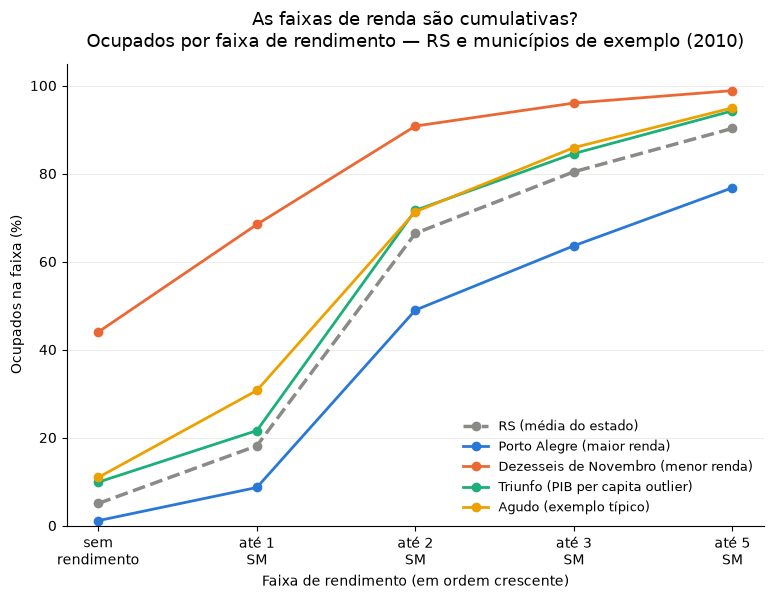

In [4]:
#análise geral da renda

# Gráfico de verificação — as colunas de faixa de renda são cumulativas?
# Município do RS, Censo 2010 (Atlas do Desenvolvimento Humano no Brasil)
#
# Não é um dos gráficos das perguntas de análise: é um gráfico de checagem,
# pra confirmar visualmente que "% até 1 SM", "% até 2 SM" etc. formam uma
# distribuição acumulada (cada faixa >= a anterior, convergindo perto de 100%)
# e não faixas mutuamente exclusivas.


faixas_cols = [
    "% dos ocupados sem rendimento 2010",
    "% dos ocupados com rendimento de até 1 salário mínimo 2010",
    "% dos ocupados com rendimento de até 2 salários mínimo 2010",
    "% dos ocupados com rendimento de até 3 salários mínimo 2010",
    "% dos ocupados com rendimento de até 5 salários mínimo 2010",
]
for c in faixas_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# rótulos curtos pro eixo x, na ordem certa da faixa
rotulos_faixa = ["sem\nrendimento", "até 1\nSM", "até 2\nSM", "até 3\nSM", "até 5\nSM"]

# ---------------------------------------------------------------
# 2. Seleção das linhas: média do RS (linha já existe agregada no
#    dataset) + municípios de exemplo, escolhidos por contraste
#    (maior renda, menor renda, outlier de PIB per capita, e um
#    município "comum" no meio da distribuição)
# ---------------------------------------------------------------
territorios_exemplo = [
    ("Rio Grande do Sul", "RS (média do estado)"),
    ("Porto Alegre (RS)", "Porto Alegre (maior renda)"),
    ("Dezesseis de Novembro (RS)", "Dezesseis de Novembro (menor renda)"),
    ("Triunfo (RS)", "Triunfo (PIB per capita outlier)"),
    ("Agudo (RS)", "Agudo (exemplo típico)"),
]

serie = {}
for nome_base, rotulo in territorios_exemplo:
    linha = df[df["Territorialidades"] == nome_base]
    if linha.empty:
        print(f"Aviso: '{nome_base}' não encontrado no dataset, pulando.")
        continue
    serie[rotulo] = linha.iloc[0][faixas_cols].values.astype(float)

# ---------------------------------------------------------------
# 3. Gráfico
# ---------------------------------------------------------------
# RS como linha de referência (cinza, tracejada); municípios em cores
# categóricas (ordem fixa, paleta validada para pares adjacentes)
CORES = {
    "RS (média do estado)": "#8a8a86",
    "Porto Alegre (maior renda)": "#2a78d6",
    "Dezesseis de Novembro (menor renda)": "#eb6834",
    "Triunfo (PIB per capita outlier)": "#1baf7a",
    "Agudo (exemplo típico)": "#eda100",
}

fig, ax = plt.subplots(figsize=(9, 6))
x = range(len(rotulos_faixa))

for rotulo, valores in serie.items():
    is_rs = rotulo.startswith("RS")
    ax.plot(
        x,
        valores,
        marker="o",
        markersize=6,
        linewidth=2.5 if is_rs else 2,
        linestyle="--" if is_rs else "-",
        color=CORES[rotulo],
        label=rotulo,
        zorder=3 if is_rs else 2,
    )

ax.set_xticks(list(x))
ax.set_xticklabels(rotulos_faixa)
ax.set_ylim(0, 105)

ax.set_title(
    "As faixas de renda são cumulativas?\nOcupados por faixa de rendimento — RS e municípios de exemplo (2010)",
    fontsize=13,
    pad=12,
)
ax.set_xlabel("Faixa de rendimento (em ordem crescente)")
ax.set_ylabel("Ocupados na faixa (%)")

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="-", linewidth=0.5, color="#e5e5e0", zorder=0)
ax.set_axisbelow(True)

ax.legend(frameon=False, loc="lower right", fontsize=9)

# plt.tight_layout()
# plt.savefig("grafico_check_cumulativo_faixas_renda.png", dpi=150, bbox_inches="tight")
plt.show()


Limites das faixas (%): [np.float64(12.4), np.float64(29.8), np.float64(47.2), np.float64(64.5)]


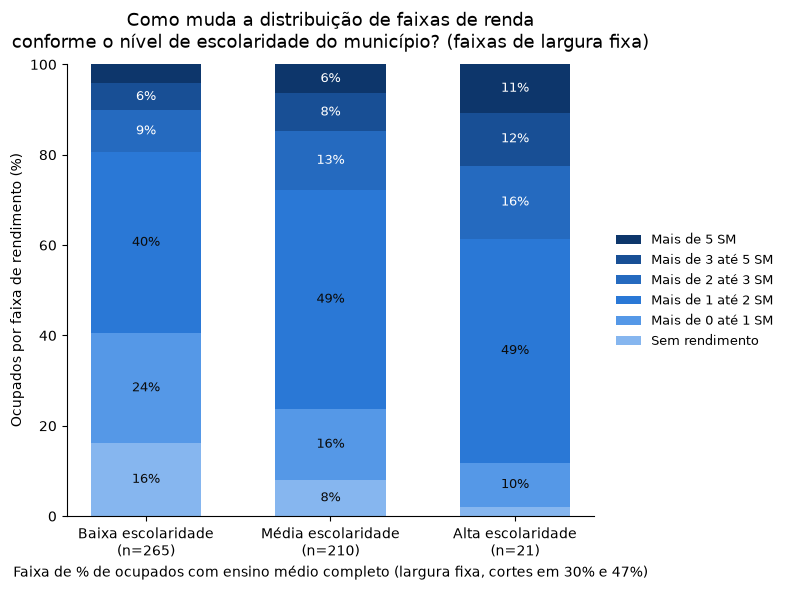

In [5]:
#Gráfico pergunta "Como muda a distribuição de faixas de renda conformeo nível de escolaridade do município?"

import numpy as np

col_escolaridade = "% dos ocupados com ensino médio completo 2010"
cols_faixas_cumulativas = [
    "% dos ocupados sem rendimento 2010",
    "% dos ocupados com rendimento de até 1 salário mínimo 2010",
    "% dos ocupados com rendimento de até 2 salários mínimo 2010",
    "% dos ocupados com rendimento de até 3 salários mínimo 2010",
    "% dos ocupados com rendimento de até 5 salários mínimo 2010",
]
for c in [col_escolaridade] + cols_faixas_cumulativas:
    municipios[c] = pd.to_numeric(municipios[c], errors="coerce")

municipios = municipios.dropna(subset=[col_escolaridade] + cols_faixas_cumulativas)

# ---------------------------------------------------------------
#    Conversão das faixas cumulativas em faixas mutuamente exclusivas
#    (checado antes: até_1 >= sem_rendimento, até_2 >= até_1, etc. —
#    são cumulativas, não faixas independentes)
# ---------------------------------------------------------------
nomes_faixas = ["Sem rendimento", "Mais de 0 até 1 SM", "Mais de 1 até 2 SM",
                 "Mais de 2 até 3 SM", "Mais de 3 até 5 SM", "Mais de 5 SM"]
 
# remove as colunas de faixa se a célula for rodada de novo, pra não duplicar
municipios = municipios.drop(columns=nomes_faixas, errors="ignore")

sem_rendimento, ate_1, ate_2, ate_3, ate_5 = [municipios[c] for c in cols_faixas_cumulativas]

faixas_exclusivas = pd.DataFrame({
    "Sem rendimento": sem_rendimento,
    "Mais de 0 até 1 SM": ate_1 - sem_rendimento,
    "Mais de 1 até 2 SM": ate_2 - ate_1,
    "Mais de 2 até 3 SM": ate_3 - ate_2,
    "Mais de 3 até 5 SM": ate_5 - ate_3,
    "Mais de 5 SM": 100 - ate_5,
})

assert (faixas_exclusivas.min() >= -0.01).all(), "faixa negativa encontrada — checar dados"
municipios = pd.concat([municipios, faixas_exclusivas], axis=1)

# ---------------------------------------------------------------
#    Agrupamento por faixa de escolaridade. Os 3 grupos ficam com o MESMO
#    intervalo de pontos percentuais, mas NÃO com a mesma quantidade
#    de municípios: como a maioria dos municípios do RS está
#    concentrada na faixa baixa/média de escolaridade, o grupo "alta"
#    acaba com poucos municípios — vale checar o n de cada grupo antes
#    de interpretar o gráfico.
# ---------------------------------------------------------------
municipios["faixa_escolaridade"], limites = pd.cut(
    municipios[col_escolaridade], 3,
    labels=["Baixa escolaridade", "Média escolaridade", "Alta escolaridade"],
    retbins=True,
)
print("\nLimites das faixas (%):", [round(b, 1) for b in limites])

nomes_faixas = list(faixas_exclusivas.columns)
medias_por_faixa = municipios.groupby("faixa_escolaridade", observed=True)[nomes_faixas].mean()
contagem_por_faixa = municipios.groupby("faixa_escolaridade", observed=True).size()


# ---------------------------------------------------------------
#  Gráfico — barras 100% empilhadas, rampa sequencial (1 tom, claro->escuro)
# ---------------------------------------------------------------
CORES_SEQUENCIAIS = ["#86b6ef", "#5598e7", "#2a78d6", "#256abf", "#184f95", "#0d366b"]

fig, ax = plt.subplots(figsize=(8, 6))

grupos = medias_por_faixa.index.tolist()
x = np.arange(len(grupos))
base = np.zeros(len(grupos))

for faixa, cor in zip(nomes_faixas, CORES_SEQUENCIAIS):
    valores = medias_por_faixa[faixa].values
    ax.bar(x, valores, bottom=base, color=cor, width=0.6, label=faixa)

    for i, v in enumerate(valores):
        if v >= 5:
            ax.text(
                x[i], base[i] + v / 2, f"{v:.0f}%",
                ha="center", va="center", fontsize=9,
                color="white" if faixa in ("Mais de 2 até 3 SM", "Mais de 3 até 5 SM", "Mais de 5 SM") else "#0b0b0b",
            )
    base += valores

ax.set_xticks(x)
ax.set_xticklabels([f"{g}\n(n={contagem_por_faixa[g]})" for g in grupos])
ax.set_ylim(0, 100)

ax.set_title(
    "Como muda a distribuição de faixas de renda\nconforme o nível de escolaridade do município? (faixas de largura fixa)",
    fontsize=13, pad=12,
)
ax.set_xlabel(f"Faixa de % de ocupados com ensino médio completo (largura fixa, cortes em {limites[1]:.0f}% e {limites[2]:.0f}%)")
ax.set_ylabel("Ocupados por faixa de rendimento (%)")

ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

handles, labels = ax.get_legend_handles_labels()
handles, labels = handles[::-1], labels[::-1]
ax.legend(handles, labels, frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)


plt.tight_layout()
plt.show()